In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

data = pd.read_excel("event_participation_500 data.xlsx")
print(data.head())
print(data.info())

Saving event_participation_500 data.xlsx to event_participation_500 data.xlsx
  Event_ID              Event_Name       Location           Date_Time  \
0    E0001     Orientation Program     Vijayawada 2024-09-27 19:45:00   
1    E0002             Sports Meet       Kakinada 2025-04-11 15:30:00   
2    E0003  Webinar on Data Mining  Visakhapatnam 2024-04-09 16:45:00   
3    E0004             Alumni Meet  Visakhapatnam 2024-12-09 14:15:00   
4    E0005             Sports Meet     Surampalem 2025-04-04 18:15:00   

   Attendee_Name            Attendee_Email  Attendee_Phone  
0  Attendee_0001  attendee0001@example.com      9523734972  
1  Attendee_0002  attendee0002@example.com      9998717130  
2  Attendee_0003  attendee0003@example.com      9748061058  
3  Attendee_0004  attendee0004@example.com      9880932287  
4  Attendee_0005  attendee0005@example.com      9130349564  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
print("Missing values before cleaning:")
print(data.isnull().sum())
data = data.fillna("Unknown")
print("\nMissing values after cleaning:")
print(data.isnull().sum())


Missing values before cleaning:
Event_ID          0
Event_Name        0
Location          0
Date_Time         0
Attendee_Name     0
Attendee_Email    0
Attendee_Phone    0
dtype: int64

Missing values after cleaning:
Event_ID          0
Event_Name        0
Location          0
Date_Time         0
Attendee_Name     0
Attendee_Email    0
Attendee_Phone    0
dtype: int64


In [ ]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print("Missing values handled safely")


Missing values handled safely


In [ ]:
print("Duplicate rows before:", data.duplicated().sum())
data = data.drop_duplicates()
print("Duplicate rows after:", data.duplicated().sum())
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]
print("Duplicates and outliers removed safely")

Duplicate rows before: 0
Duplicate rows after: 0
Duplicates and outliers removed safely


In [ ]:
print("Dataset columns:")
print(data.columns)
print("\nDataset shape:", data.shape)
data.head()


Dataset columns:
Index(['Event_ID', 'Event_Name', 'Location', 'Date_Time', 'Attendee_Name',
       'Attendee_Email', 'Attendee_Phone'],
      dtype='object')

Dataset shape: (500, 7)


,Event_ID,Event_Name,Location,Date_Time,Attendee_Name,Attendee_Email,Attendee_Phone
0,E0001,Orientation Program,Vijayawada,2024-09-27 19:45:00,Attendee_0001,attendee0001@example.com,9523734972
1,E0002,Sports Meet,Kakinada,2025-04-11 15:30:00,Attendee_0002,attendee0002@example.com,9998717130
2,E0003,Webinar on Data Mining,Visakhapatnam,2024-04-09 16:45:00,Attendee_0003,attendee0003@example.com,9748061058
3,E0004,Alumni Meet,Visakhapatnam,2024-12-09 14:15:00,Attendee_0004,attendee0004@example.com,9880932287
4,E0005,Sports Meet,Surampalem,2025-04-04 18:15:00,Attendee_0005,attendee0005@example.com,9130349564


### Event Distribution by Name

Let's visualize the number of occurrences for each `Event_Name`.

/tmp/ipykernel_6850/3188299097.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Event_Name', y='Count', data=event_name_counts, palette='viridis')


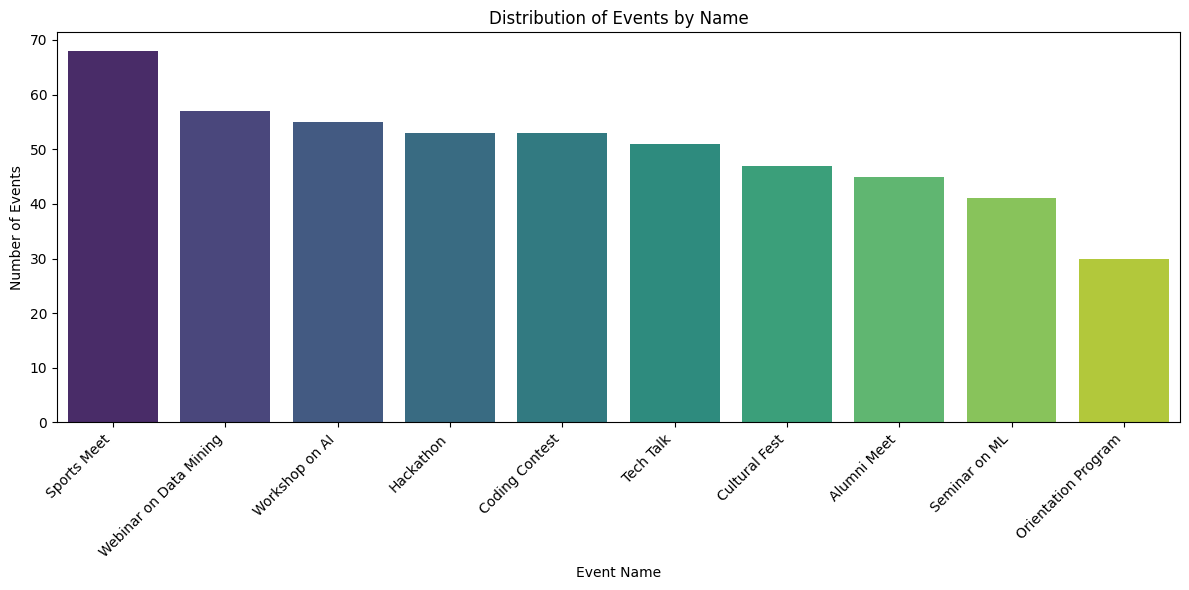

Top 5 Event Names:
               Event_Name  Count
0             Sports Meet     68
1  Webinar on Data Mining     57
2          Workshop on AI     55
3               Hackathon     53
4          Coding Contest     53


In [ ]:
# Count occurrences of each Event_Name
event_name_counts = data['Event_Name'].value_counts().reset_index()
event_name_counts.columns = ['Event_Name', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='Event_Name', y='Count', data=event_name_counts, palette='viridis')
plt.title('Distribution of Events by Name')
plt.xlabel('Event Name')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 Event Names:")
print(event_name_counts.head())

### Event Distribution by Location

Now, let's see which locations host the most events.

/tmp/ipykernel_6850/457676295.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Location', y='Count', data=location_counts, palette='plasma')


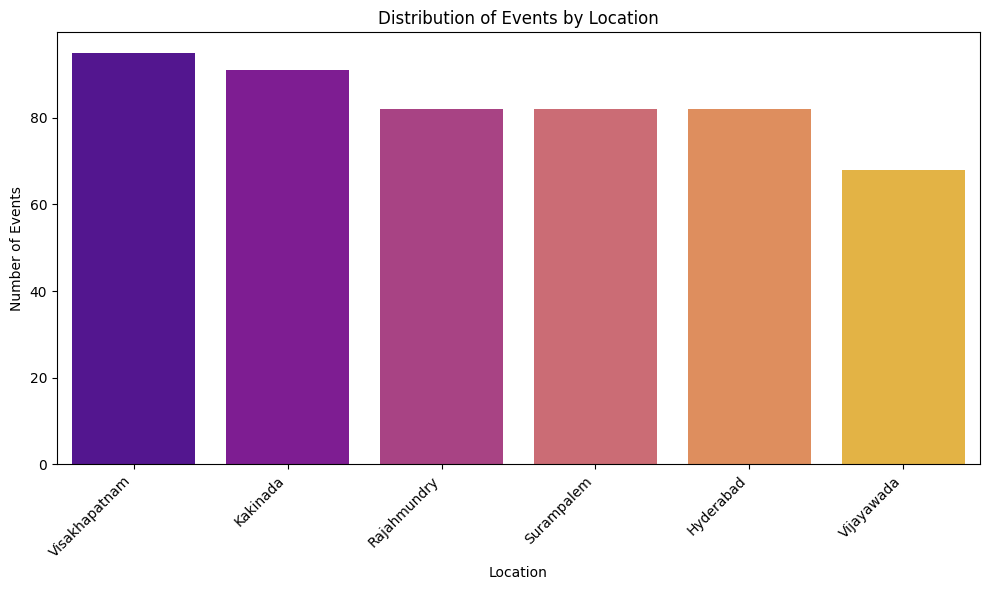

Top 5 Locations:
        Location  Count
0  Visakhapatnam     95
1       Kakinada     91
2    Rajahmundry     82
3     Surampalem     82
4      Hyderabad     82


In [ ]:
# Count occurrences of each Location
location_counts = data['Location'].value_counts().reset_index()
location_counts.columns = ['Location', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Location', y='Count', data=location_counts, palette='plasma')
plt.title('Distribution of Events by Location')
plt.xlabel('Location')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 Locations:")
print(location_counts.head())

In [ ]:
# Correct column name and create date parts
data['Date_Time'] = pd.to_datetime(data['Date_Time'], errors='coerce')
data['Year'] = data['Date_Time'].dt.year
data['Month'] = data['Date_Time'].dt.month
data['Day'] = data['Date_Time'].dt.day
print("Data transformation completed")
data[['Date_Time', 'Year', 'Month', 'Day']].head()


Data transformation completed


/tmp/ipykernel_268/2181146824.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date_Time'] = pd.to_datetime(data['Date_Time'], errors='coerce')


,Date_Time,Year,Month,Day
0,2024-09-27 19:45:00,2024,9,27
1,2025-04-11 15:30:00,2025,4,11
2,2024-04-09 16:45:00,2024,4,9
3,2024-12-09 14:15:00,2024,12,9
4,2025-04-04 18:15:00,2025,4,4


In [ ]:
reduced_data = data[['Event_Name', 'Location', 'Year', 'Month', 'Day']]
print("Data reduction completed")
reduced_data.head()


Data reduction completed


,Event_Name,Location,Year,Month,Day
0,Orientation Program,Vijayawada,2024,9,27
1,Sports Meet,Kakinada,2025,4,11
2,Webinar on Data Mining,Visakhapatnam,2024,4,9
3,Alumni Meet,Visakhapatnam,2024,12,9
4,Sports Meet,Surampalem,2025,4,4


In [ ]:
# 1. Count number of events per attendee
participant_counts = (
    data.groupby('Attendee_Name')['Event_ID']
        .nunique()          # how many different events they attended
        .reset_index(name='Events_Attended')
        .sort_values('Events_Attended', ascending=False)
)

# 2. Show top 10 participants
print(participant_counts.head(10))

# 3. Person who participated in most events
top_participant = participant_counts.iloc[0]
print("Top participant:", top_participant['Attendee_Name'])
print("Number of events attended:", top_participant['Events_Attended'])


     Attendee_Name  Events_Attended
499  Attendee_0500                1
0    Attendee_0001                1
1    Attendee_0002                1
2    Attendee_0003                1
483  Attendee_0484                1
482  Attendee_0483                1
481  Attendee_0482                1
480  Attendee_0481                1
479  Attendee_0480                1
478  Attendee_0479                1
Top participant: Attendee_0500
Number of events attended: 1


In [ ]:
# 1. Count participants per event (using Event_ID)
event_counts = (
    data.groupby(['Event_ID', 'Event_Name', 'Location'])['Attendee_Name']
        .nunique()   # or .count() if you want raw rows
        .reset_index(name='Participants_Count')
        .sort_values('Participants_Count', ascending=False)
)

# 2. Show top 10 events
print(event_counts.head(10))

# 3. Event with maximum participants
top_event = event_counts.iloc[0]
print("Most participated event:")
print("Event ID:", top_event['Event_ID'])
print("Event Name:", top_event['Event_Name'])
print("Location:", top_event['Location'])
print("Participants:", top_event['Participants_Count'])


    Event_ID              Event_Name       Location  Participants_Count
499    E0500  Webinar on Data Mining       Kakinada                   1
0      E0001     Orientation Program     Vijayawada                   1
1      E0002             Sports Meet       Kakinada                   1
2      E0003  Webinar on Data Mining  Visakhapatnam                   1
483    E0484           Cultural Fest     Vijayawada                   1
482    E0483          Workshop on AI      Hyderabad                   1
481    E0482           Cultural Fest  Visakhapatnam                   1
480    E0481          Workshop on AI     Surampalem                   1
479    E0480             Sports Meet       Kakinada                   1
478    E0479             Sports Meet      Hyderabad                   1
Most participated event:
Event ID: E0500
Event Name: Webinar on Data Mining
Location: Kakinada
Participants: 1


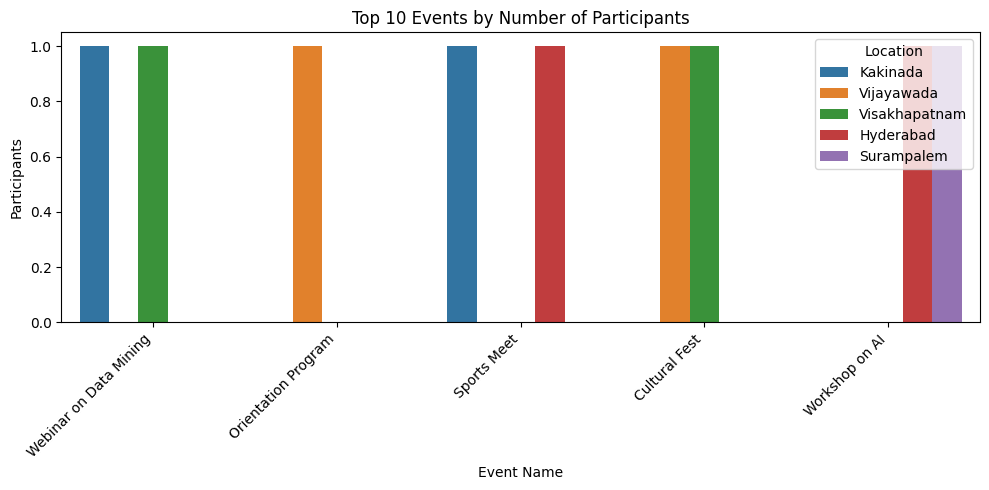

In [ ]:
# take top 10 events by participants
top_events = event_counts.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_events,
    x='Event_Name',
    y='Participants_Count',
    hue='Location'
)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Events by Number of Participants')
plt.ylabel('Participants')
plt.xlabel('Event Name')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

# Load data from the existing 'data' DataFrame
df = data.copy()

# Count participants per event
event_counts = df.groupby('Event_Name').size().reset_index(name='Participants')

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42) # Added random_state for reproducibility
event_counts['Cluster'] = kmeans.fit_predict(event_counts[['Participants']])

print(event_counts)

               Event_Name  Participants  Cluster
0             Alumni Meet            45        1
1          Coding Contest            53        0
2           Cultural Fest            47        1
3               Hackathon            53        0
4     Orientation Program            30        2
5           Seminar on ML            41        1
6             Sports Meet            68        0
7               Tech Talk            51        0
8  Webinar on Data Mining            57        0
9          Workshop on AI            55        0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Load data from the existing 'data' DataFrame
df = data.copy()

# Count participants per event
event_counts = df.groupby('Event_Name').size().reset_index(name='Participants')

# Create label
def label(p):
    if p < 30:
        return "Low"
    elif p < 70:
        return "Medium"
    else:
        return "High"

event_counts['Event_Status'] = event_counts['Participants'].apply(label)

# Convert Event_Name to numeric
le = LabelEncoder()
event_counts['Event_Code'] = le.fit_transform(event_counts['Event_Name'])

# Features & Target
X = event_counts[['Event_Code']]
y = event_counts['Event_Status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Predicted:", y_pred)

Predicted: ['Medium' 'Medium']


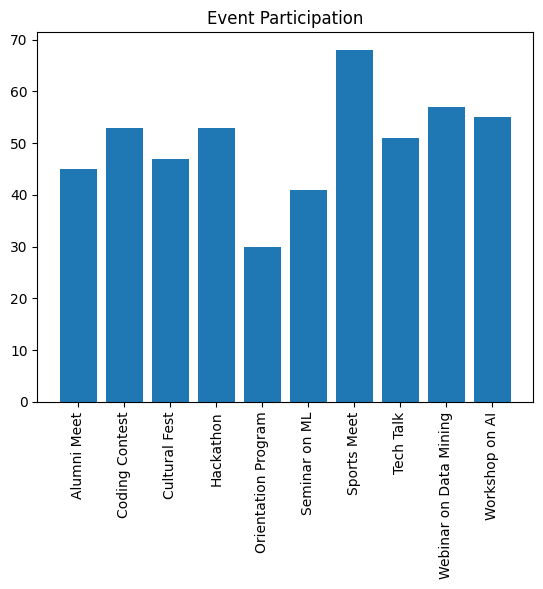

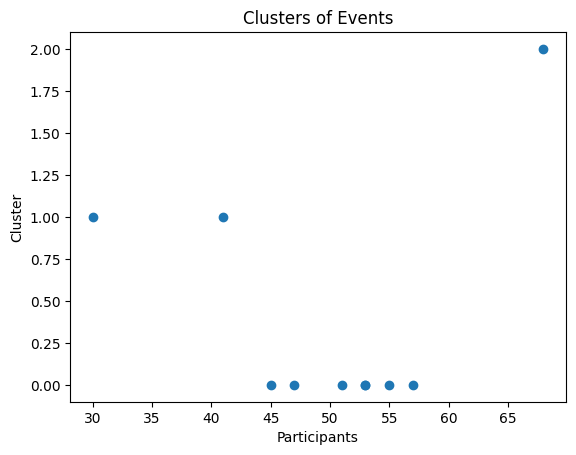

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Re-create event_counts and apply KMeans to ensure 'Cluster' column exists for plotting
df_plot = data.copy()
event_counts_plot = df_plot.groupby('Event_Name').size().reset_index(name='Participants')

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
event_counts_plot['Cluster'] = kmeans.fit_predict(event_counts_plot[['Participants']])

# Bar chart
plt.bar(event_counts_plot['Event_Name'], event_counts_plot['Participants'])
plt.xticks(rotation=90)
plt.title("Event Participation")
plt.show()

# Scatter (Clustering)
plt.scatter(event_counts_plot['Participants'], event_counts_plot['Cluster'])
plt.xlabel("Participants")
plt.ylabel("Cluster")
plt.title("Clusters of Events")
plt.show()

Missing Values:
 Event_ID          0
Event_Name        0
Location          0
Date_Time         0
Attendee_Name     0
Attendee_Email    0
Attendee_Phone    0
dtype: int64

Cluster Counts:
 Cluster
0    500
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


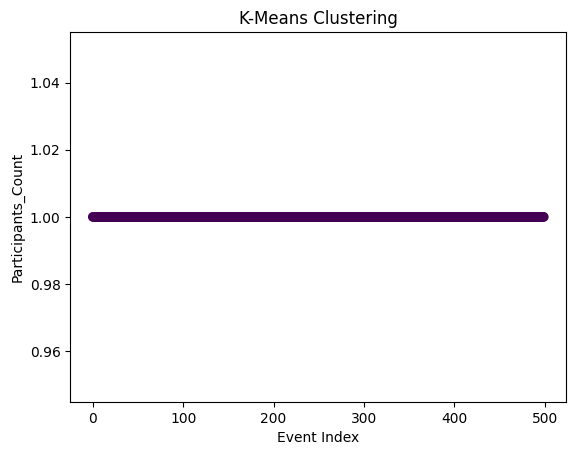


Accuracy: 100.0

Confusion Matrix:
 [[100]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


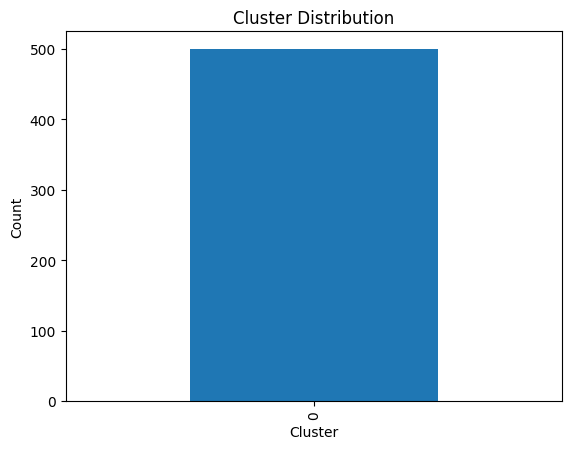

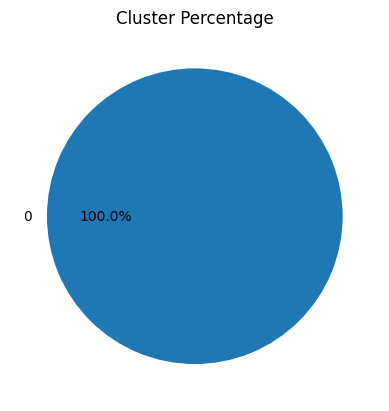

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_excel("event_participation_500 data.xlsx")

# -----------------------------
# 🟡 Data Preprocessing
# -----------------------------
print("Missing Values:\n", df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values (addressing FutureWarning)
df = df.ffill()

# Calculate participants per event by grouping on Event_Name and Location
event_data = df.groupby(['Event_Name', 'Location']).agg(
    Participants_Count=('Attendee_Name', 'nunique')
).reset_index()

# Encode categorical data for clustering/classification features
le = LabelEncoder()
event_data['Event_Name_Encoded'] = le.fit_transform(event_data['Event_Name'])
event_data['Location_Encoded'] = le.fit_transform(event_data['Location'])

# -----------------------------
# 🔵 Clustering (K-Means)
# -----------------------------
# Use Participants_Count for clustering
X_cluster = event_data[['Participants_Count']]

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10) # Added n_init to suppress warning
event_data['Cluster'] = kmeans.fit_predict(X_cluster)

print("\nCluster Counts:\n", event_data['Cluster'].value_counts())

# Plot Clusters
plt.figure()
plt.scatter(event_data['Participants_Count'], event_data['Cluster'], c=event_data['Cluster'])
plt.title("K-Means Clustering")
plt.xlabel("Participants_Count")
plt.ylabel("Cluster")
plt.show()

# -----------------------------
# 🔴 Classification (Decision Tree)
# -----------------------------
# Create labels for classification based on participant count, similar to previous cells
def label_event_status(p):
    if p < 30:
        return "Low"
    elif p < 70:
        return "Medium"
    else:
        return "High"

event_data['Event_Status'] = event_data['Participants_Count'].apply(label_event_status)
event_data['Event_Status_Encoded'] = le.fit_transform(event_data['Event_Status'])

X = event_data[['Event_Name_Encoded', 'Location_Encoded', 'Participants_Count']] # Features for classification
y = event_data['Event_Status_Encoded'] # Target is the new status label

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Added random_state

# Train model
model = DecisionTreeClassifier(random_state=42) # Added random_state
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy * 100)

# Confusion Matrix
print("\nConfusion Matrix:
", confusion_matrix(y_test, y_pred))

# -----------------------------
# 📊 Visualization
# -----------------------------
# Bar Chart for Cluster Distribution
plt.figure()
event_data['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

# Pie Chart for Cluster Percentage
plt.figure()
event_data['Cluster'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Cluster Percentage")
plt.ylabel("")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- Code to define event_data (from Zjnkap5bruDe) ---
# 'data' DataFrame is already available from previous executions.
# Calculate participants per event by grouping on Event_Name and Location
event_data = data.groupby(['Event_Name', 'Location']).agg(
    Participants_Count=('Attendee_Name', 'nunique')
).reset_index()

# Encode categorical data for clustering/classification features
le = LabelEncoder()
event_data['Event_Name_Encoded'] = le.fit_transform(event_data['Event_Name'])
event_data['Location_Encoded'] = le.fit_transform(event_data['Location'])

# --- Code for classification (from aFFVAA3lPo6F) ---
# Create df by explicitly selecting only the numerical/encoded features
df = event_data[[
    'Event_Name_Encoded',
    'Location_Encoded',
    'Participants_Count'
]].copy()

# Now rename the columns in df to the desired names for the model features
df.rename(columns={
    'Event_Name_Encoded': 'Event_Type',
    'Location_Encoded': 'Location',
    'Participants_Count': 'Participants'
}, inplace=True)

# Create Labels (Low, Medium, High)
def label_participation(x):
    if x < 50:
        return 0   # Low
    elif x < 150:
        return 1   # Medium
    else:
        return 2   # High

df['Label'] = df['Participants'].apply(label_participation)

# Split Data
X = df[['Event_Type', 'Location', 'Participants']]
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 100.0

Confusion Matrix:
[[12]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Skipping ROC for Class 1: No positive samples in y_test.
Skipping ROC for Class 2: No positive samples in y_test.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


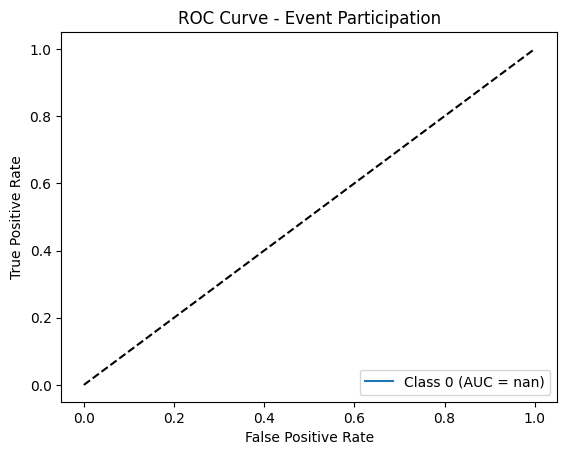

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_curve, auc

# The original error was FileNotFoundError because 'event_participation_500.xlsx' does not exist.
# Using the already prepared 'df' from the previous cell (93e1fcd5) is more efficient
# and avoids re-loading and re-preprocessing data.
# 'df' is available in the kernel state with columns 'Event_Type', 'Location', 'Participants', 'Label'.

# -----------------------------
# Prepare Data
# -----------------------------
X = df[['Event_Type', 'Location', 'Participants']]
y = df['Label']

# Binarize labels for ROC (multi-class)
y_bin = label_binarize(y, classes=[0,1,2])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# -----------------------------
# Train Model
# -----------------------------
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# -----------------------------
# Predict Probabilities
# -----------------------------
y_score = model.predict_proba(X_test)

# -----------------------------
# ROC Curve
# -----------------------------
plt.figure()

for i in range(y_bin.shape[1]): # Iterate over the number of classes (outputs)
    # Check if there are any positive samples for the current class in y_test
    # And ensure the corresponding probability array exists in y_score
    if y_test[:, i].sum() > 0 and i < len(y_score):
        # The y_score for each output is an array.
        # If it's a 2D array with only one column (as indicated by the error),
        # we should use the first column (index 0).
        # If it has more than one column, then index 1 is usually the positive class.
        current_y_score_array = y_score[i]

        if current_y_score_array.ndim == 2 and current_y_score_array.shape[1] > 1:
            y_prob_for_class = current_y_score_array[:, 1]
        elif current_y_score_array.ndim == 2 and current_y_score_array.shape[1] == 1:
            y_prob_for_class = current_y_score_array[:, 0]
        elif current_y_score_array.ndim == 1:
            y_prob_for_class = current_y_score_array
        else:
            y_prob_for_class = current_y_score_array.ravel() # Fallback

        fpr, tpr, _ = roc_curve(y_test[:, i], y_prob_for_class)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')
    elif i < len(y_score) and y_test[:, i].sum() == 0:
        print(f"Skipping ROC for Class {i}: No positive samples in y_test.")
    else:
        print(f"Skipping ROC for Class {i}: No corresponding probability array in y_score.")

plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Event Participation")
plt.legend(loc="lower right")
plt.show()